In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt


sys.path.append('../')

In [4]:
def something(N, n0, L):
    return n0 * N ** (1/(n0*L))/(np.e ** (1/L))

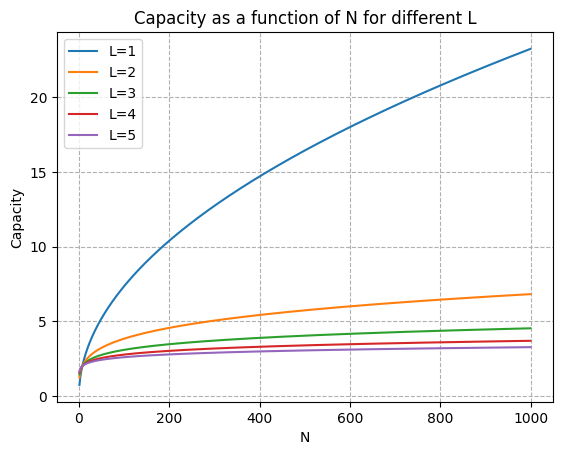

In [10]:
n0 = 2 # Input space dimension
L = 3

N = np.arange(1, 1000)

for L in [1, 2, 3, 4, 5]:
    plt.plot(N, something(N, n0, L), label=f'L={L}')
plt.xlabel('N')
plt.ylabel('Capacity')
plt.title('Capacity as a function of N for different L')
plt.legend()
# plt.xscale('log')
# plt.yscale('log')
plt.grid(True, which="both", ls="--")
plt.show()


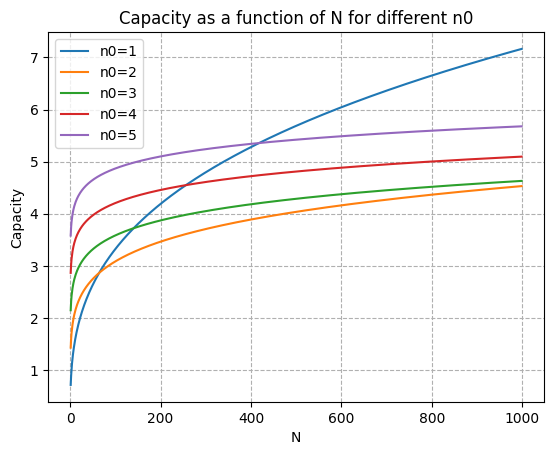

In [11]:
L = 3

for n0 in [1, 2, 3, 4, 5]:
    plt.plot(N, something(N, n0, L), label=f'n0={n0}')
plt.xlabel('N')
plt.ylabel('Capacity')
plt.title('Capacity as a function of N for different n0')
plt.legend()
# plt.xscale('log')
# plt.yscale('log')
plt.grid(True, which="both", ls="--")
plt.show()


# Exact max region number

$$
R_\mathrm{max} = \left(   \prod_{i=1}^{L-1} \left\lfloor \frac{n_i}{n_0} \right\rfloor^{n_0} \right) \sum_{j=0}^{n_0} \binom{n_L}{j}
$$

In [63]:
import math

def calculate_R_max(n):
    """
    Calculates R_max given a list of values n = [n_0, n_1, ..., n_L].
    """
    if len(n) < 2:
        raise ValueError("The sequence 'n' must contain at least two elements (n_0 and n_L).")
    
    n_0 = n[0]
    n_L = n[-1]
    
    if n_0 == 0:
        raise ZeroDivisionError("n_0 cannot be zero because it is used as a denominator.")

    # 1. Product part: \prod_{i=1}^{L-1} \lfloor n_i / n_0 \rfloor^{n_0}
    # n[1:-1] slices the list to get exactly elements n_1 through n_{L-1}
    # We use integer division (//) which naturally acts as the floor function here.
    product_part = math.prod((n_i // n_0) ** n_0 for n_i in n[1:-1])

    # 2. Summation part: \sum_{j=0}^{n_0} \binom{n_L}{j}
    # math.comb calculates the binomial coefficient
    sum_part = sum(math.comb(n_L, j) for j in range(n_0 + 1))

    # 3. Multiply them together
    R_max = product_part * sum_part
    
    return R_max

In [ ]:
def estimate_R_max(n_neuron, L, n0):
    return (n_neuron/n0)**(n0*L) * math.exp(n0)

In [69]:
n_values = [2,25,25,25]
result = calculate_R_max(n_values)
print(f"R_max = {result}")

est = estimate_R_max(n_neuron=25, L=3, n0=2)
print(f"Estimated R_max = {est:.0f}")
print(f"Ratio of estimated to calculated R_max: {est/result:.2f}")

R_max = 6759936
Estimated R_max = 28187012
Ratio of estimated to calculated R_max: 4.17
